<a href="https://colab.research.google.com/github/ilseeu01/2025-DCC-Data-Creator-Camp/blob/mission1/BGT%EB%AA%A8%EB%8D%B81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# [Step 0 & 1] 환경 설정, 압축 해제, 데이터 로더 생성 통합
# 실행 환경: Google Colab
import os
import zipfile
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---------------------------------------------------------
# 1. 경로 및 환경 설정 (Configuration)
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

class Config:
    ZIP_PATH = '/content/drive/MyDrive/patches_expert.zip'
    CSV_PATH = '/content/drive/MyDrive/patch_labels_expert.csv'
    EXTRACT_PATH = '/content/BGT/images'  # 압축 풀릴 위치

    IMG_SIZE = 224
    BATCH_SIZE = 16
    SEED = 42
    NUM_WORKERS = 2


# 시드 고정
def seed_everything(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(Config.SEED)

# ---------------------------------------------------------
# 2. 데이터 압축 해제 (Step 0)
# ---------------------------------------------------------
if not os.path.exists(Config.EXTRACT_PATH):
    print(f"📂 압축 해제 중... ({Config.ZIP_PATH} -> {Config.EXTRACT_PATH})")
    os.makedirs(Config.EXTRACT_PATH, exist_ok=True)
    try:
        with zipfile.ZipFile(Config.ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(Config.EXTRACT_PATH)
        print("✅ 압축 해제 완료!")
    except FileNotFoundError:
        print(f"❌ 파일을 찾을 수 없습니다: {Config.ZIP_PATH}")
        print("   -> 경로를 다시 확인하거나 구글 드라이브 마운트가 되었는지 확인하세요.")
else:
    print("✅ 이미 압축이 해제되어 있습니다.")

# ---------------------------------------------------------
# 3. Dataset 클래스 (Step 1 - Lean Version)
# ---------------------------------------------------------
class BGTDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 이미지 파일명 (CSV의 patch 컬럼이 파일명이라고 가정)
        img_name = row['patch'] if 'patch' in row else row['filename']
        img_path = os.path.join(self.img_dir, img_name)

        # 이미지 로드
        image = cv2.imread(img_path)

        if image is None:
            # 로드 실패 시 검은 이미지 반환 (에러 방지)
            image = np.zeros((Config.IMG_SIZE, Config.IMG_SIZE, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR -> RGB

        # 증강 적용
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # Label (회귀 점수)
        label = torch.tensor(row['grade'], dtype=torch.float32)

        return image, label

# ---------------------------------------------------------
# 4. Augmentation (태블릿 데이터용)
# ---------------------------------------------------------
# Train: 과적합 방지를 위해 약간의 변형 추가
train_transform = A.Compose([
    A.Resize(Config.IMG_SIZE, Config.IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),  # 약한 노이즈
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Val/Test: 정규화만 수행
val_transform = A.Compose([
    A.Resize(Config.IMG_SIZE, Config.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ---------------------------------------------------------
# 5. 데이터 분할 및 로더 생성
# ---------------------------------------------------------
if os.path.exists(Config.CSV_PATH):
    df = pd.read_csv(Config.CSV_PATH)

    # 컬럼명 확인 및 통일 ('patch' -> 'filename' 처럼 취급)
    if 'patch' in df.columns:
        print(f"📄 데이터 로드 성공: {len(df)}개 샘플")
    else:
        print(f"⚠️ 경고: 'patch' 컬럼이 없습니다. 컬럼명: {df.columns}")

    # Stratified Split (8:1:1)
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=Config.SEED)

    # class_id가 있으면 그것 기준, 없으면 그냥 랜덤 (예외처리)
    stratify_col = df['class_id'] if 'class_id' in df.columns else None

    for train_idx, temp_idx in split.split(df, stratify_col):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        temp_df = df.iloc[temp_idx].reset_index(drop=True)

    split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=Config.SEED)
    stratify_col_temp = temp_df['class_id'] if 'class_id' in temp_df.columns else None

    for val_idx, test_idx in split2.split(temp_df, stratify_col_temp):
        val_df = temp_df.iloc[val_idx].reset_index(drop=True)
        test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    print(f"✅ 데이터셋 준비 완료:")
    print(f"   - Train: {len(train_df)}")
    print(f"   - Val  : {len(val_df)}")
    print(f"   - Test : {len(test_df)}")

    # DataLoader 생성
    train_loader = DataLoader(BGTDataset(train_df, Config.EXTRACT_PATH, train_transform),
                              batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
    val_loader = DataLoader(BGTDataset(val_df, Config.EXTRACT_PATH, val_transform),
                            batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
    test_loader = DataLoader(BGTDataset(test_df, Config.EXTRACT_PATH, val_transform),
                             batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

else:
    print(f"❌ CSV 파일을 찾을 수 없습니다: {Config.CSV_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 이미 압축이 해제되어 있습니다.


/tmp/ipython-input-2387259311.py:100: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),  # 약한 노이즈


📄 데이터 로드 성공: 3421개 샘플
✅ 데이터셋 준비 완료:
   - Train: 2736
   - Val  : 342
   - Test : 343


🔥 밸런스 게임 시작 (Device: cuda)
⚖️ 균형 잡힌 데이터 로더 생성 완료!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1 | Train Acc: 0.1926 | Val Acc: 0.1696


Epoch 2 | Train Acc: 0.1944 | Val Acc: 0.0088


...

Epoch 16/20 | Train Loss: 0.3780 | Val Loss: 0.3966 | Val MAE: 0.7908 | Val R²: -0.0048


Epoch 17/20 | Train Loss: 0.3786 | Val Loss: 0.3967 | Val MAE: 0.7901 | Val R²: -0.0054


Epoch 18/20 | Train Loss: 0.3786 | Val Loss: 0.3965 | Val MAE: 0.7916 | Val R²: -0.0040


Epoch 19/20 | Train Loss: 0.3789 | Val Loss: 0.3967 | Val MAE: 0.7902 | Val R²: -0.0053
🛑 Early Stopping Triggered at Epoch 19

📊 최종 테스트 세트 평가 중...



🏆 [Final Test Result]
   - MAE  (평균 절대 오차): 0.7927
   - RMSE (평균 제곱근 오차): 0.9290
   - R²   (결정 계수): -0.0059


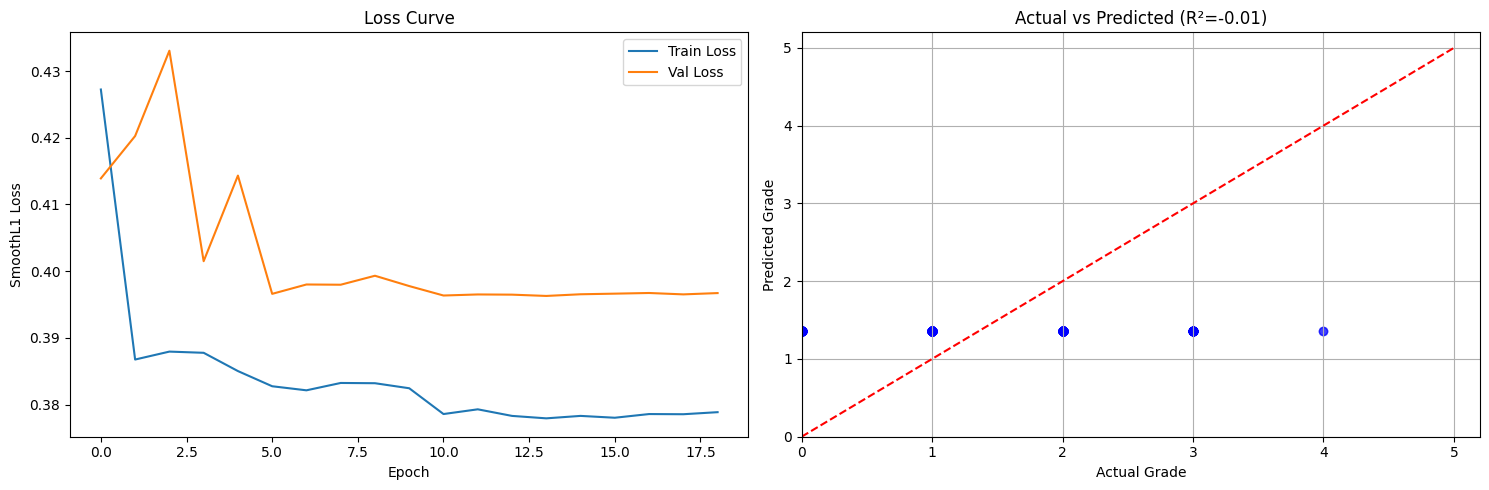

In [6]:
# [Step 2 ~ Final] EfficientNet 학습, 평가, 시각화 통합 코드
# 실행 환경: Google Colab (GPU 필요)

import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm  # PyTorch Image Models (최신 모델 라이브러리)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import copy
import numpy as np # numpy import 추가

# --- Helper Functions for Training and Validation ---
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1) # 회귀를 위해 float, unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1) # 회귀를 위해 float, unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return running_loss / len(dataloader.dataset), np.array(all_preds), np.array(all_targets)

# ---------------------------------------------------------
# 1. 모델 설계 (EfficientNet-B0 for Regression)
# ---------------------------------------------------------
class BGTScoreModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', pretrained=True):
        super(BGTScoreModel, self).__init__()
        # timm 라이브러리에서 모델 로드 (num_classes=0은 헤드 제거용)
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        # EfficientNet-B0의 feature map 개수는 1280개
        n_features = self.backbone.num_features

        # 회귀(Regression)용 헤드 장착
        # 0~5점 사이의 값을 예측하므로 출력은 1개
        self.regressor = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(n_features, 256),
            nn.Mish(), # 최신 활성화 함수 (ReLU보다 부드러움)
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return output
# [Step 2: 최종 해결책] Weighted Random Sampler 적용
# 벌점(Loss Weight) 대신, 데이터를 뽑을 때 4점짜리를 자주 뽑아서 강제 균형을 맞춤

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler, DataLoader
from tqdm import tqdm
import timm
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# --- 1. 샘플러 생성 (핵심!) ---
def create_balanced_loader(df, dataset_class, img_dir, transform, batch_size):
    # 1) 클래스별 개수 확인
    class_counts = df['grade'].round().astype(int).value_counts().sort_index()

    # 2) 각 샘플에 대한 가중치 계산 (희귀할수록 가중치 높음)
    # Weight = 1.0 / 개수
    sample_weights = []
    for _, row in df.iterrows():
        label = int(round(row['grade']))
        weight = 1.0 / class_counts[label]
        sample_weights.append(weight)

    sample_weights = torch.DoubleTensor(sample_weights)

    # 3) Sampler 생성 (이게 데이터를 골고루 뽑아줌)
    # num_samples를 전체 개수로 맞춰서 에포크 길이는 유지
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    # 4) Sampler가 장착된 DataLoader 생성
    # 주의: shuffle=False여야 함 (Sampler가 이미 섞어줌)
    loader = DataLoader(
        dataset_class(df, img_dir, transform),
        batch_size=batch_size,
        shuffle=False,      # 필수: Sampler 사용 시 False
        sampler=sampler,    # 필수: 우리가 만든 Sampler
        num_workers=2
    )
    return loader

# --- 2. 모델 설정 ---
class BGTClassModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', pretrained=True, num_classes=5):
        super(BGTClassModel, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)

    def forward(self, x):
        return self.backbone(x)

# --- 3. 실행 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 밸런스 게임 시작 (Device: {device})")

BATCH_SIZE = 16
LEARNING_RATE = 1e-4 # 안정적인 학습률
EPOCHS = 20

if 'train_df' in locals():
    # 1) 밸런스 맞춰진 로더 새로 생성 (Train만 적용, Val/Test는 그대로)
    balanced_train_loader = create_balanced_loader(
        train_df, BGTDataset, Config.EXTRACT_PATH, train_transform, BATCH_SIZE
    )
    print("⚖️ 균형 잡힌 데이터 로더 생성 완료!")

    # 2) 모델 초기화
    model = BGTClassModel(num_classes=5).to(device)

    # 3) Loss (이제 가중치 없이 평범한 CrossEntropy 사용)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    history = {'train_acc': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        # Sampler 덕분에 배치 안에 0,1,2,3,4점이 골고루 섞여 들어옴
        pbar = tqdm(balanced_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'acc': correct/total})

        train_acc = correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).long()
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = val_correct / val_total
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_bgt_balanced.pth')

    print(f"🏆 학습 종료. 최고 정확도: {best_acc:.4f}")

    # 최종 평가
    model.load_state_dict(best_model_wts)
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.long().numpy())

    print("\n📊 최종 성적표 (Sampler 적용 후)")
    print(classification_report(all_labels, all_preds, zero_division=0))

else:
    print("⚠️ 데이터가 없습니다. Step 1을 먼저 실행하세요.")
    # ---------------------------------------------------------
# 3. 메인 실행 코드 (Main Execution)
# ---------------------------------------------------------
# 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 사용 장치: {device}")

# 하이퍼파라미터
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 20 # 예시로 20, 실제론 Early Stopping으로 조절
PATIENCE = 5 # 5번 참기

# DataLoader 생성 (Step 1에서 만든 데이터셋 사용)
if 'train_df' in locals():
    # Dataset 인스턴스 다시 생성 (확실히 하기 위해)
    train_ds = BGTDataset(train_df, Config.EXTRACT_PATH, transform=train_transform)
    val_ds = BGTDataset(val_df, Config.EXTRACT_PATH, transform=val_transform)
    test_ds = BGTDataset(test_df, Config.EXTRACT_PATH, transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # 모델 초기화
    model = BGTScoreModel().to(device)

    # Loss & Optimizer
    criterion = nn.SmoothL1Loss(beta=1.0) # 이상치에 강한 Loss
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3) # 'verbose=True' 제거

    # --- 학습 루프 ---
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_counter = 0

    loss_history = {'train': [], 'val': []}

    print("\n🚀 학습 시작 (EfficientNet-B0)...")
    for epoch in range(EPOCHS):
        start_time = time.time()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_preds, val_targets = validate(model, val_loader, criterion, device)

        # LR Scheduler 업데이트
        scheduler.step(val_loss)

        # 기록
        loss_history['train'].append(train_loss)
        loss_history['val'].append(val_loss)

        # 성능 지표 계산
        val_mae = mean_absolute_error(val_targets, val_preds)
        val_r2 = r2_score(val_targets, val_preds)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val MAE: {val_mae:.4f} | Val R²: {val_r2:.4f}")

        # Best Model 저장 (Early Stopping)
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
            torch.save(model.state_dict(), 'best_bgt_model.pth') # 모델 저장
            print("  ✅ Best Model Saved!")
        else:
            early_stop_counter += 1
            if early_stop_counter >= PATIENCE:
                print(f"🛑 Early Stopping Triggered at Epoch {epoch+1}")
                break

    # --- 최종 평가 (Test Set) ---
    print("\n📊 최종 테스트 세트 평가 중...")
    model.load_state_dict(best_model_wts) # 최고 성능 모델 로드
    test_loss, test_preds, test_targets = validate(model, test_loader, criterion, device)

    test_mae = mean_absolute_error(test_targets, test_preds)
    test_mse = mean_squared_error(test_targets, test_preds)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(test_targets, test_preds)

    print(f"\n🏆 [Final Test Result]")
    print(f"   - MAE  (평균 절대 오차): {test_mae:.4f}")
    print(f"   - RMSE (평균 제곱근 오차): {test_rmse:.4f}")
    print(f"   - R²   (결정 계수): {test_r2:.4f}")

    # --- 시각화 ---
    plt.figure(figsize=(15, 5))

    # 1. Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(loss_history['train'], label='Train Loss')
    plt.plot(loss_history['val'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('SmoothL1 Loss')
    plt.legend()

    # 2. Prediction vs Actual Scatter
    plt.subplot(1, 2, 2)
    plt.scatter(test_targets, test_preds, alpha=0.5, color='blue')
    plt.plot([0, 5], [0, 5], 'r--', label='Perfect Prediction') # 대각선
    plt.title(f'Actual vs Predicted (R²={test_r2:.2f})')
    plt.xlabel('Actual Grade')
    plt.ylabel('Predicted Grade')
    plt.grid(True)
    plt.xlim(0, 5.2)
    plt.ylim(0, 5.2)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 데이터를 먼저 로드해주세요 (Step 1 실행 필요)")